In [11]:
from ucimlrepo import fetch_ucirepo 
import torch
import matplotlib.pyplot as plt
import mne

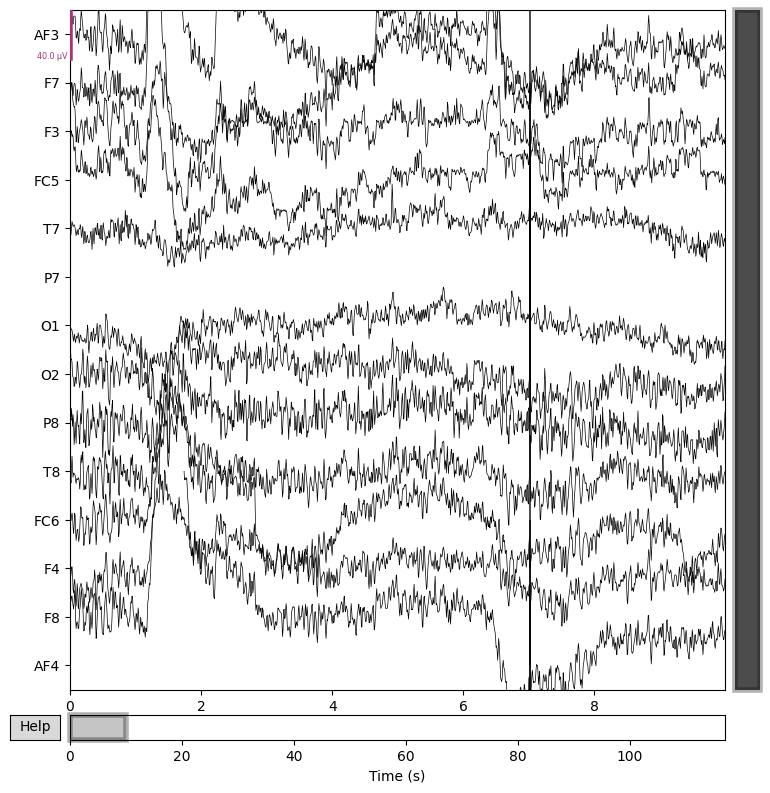

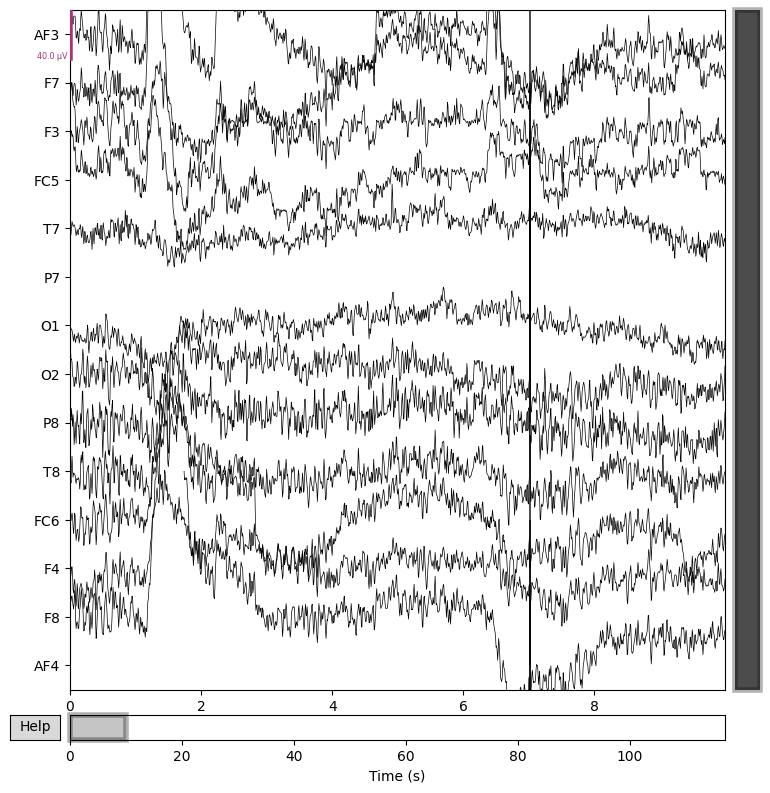

In [25]:
# fetch dataset 
eeg_eye_state = fetch_ucirepo(id=264) 
  
# data (as pandas dataframes) 
X = eeg_eye_state.data.features 
y = eeg_eye_state.data.targets 

features = torch.tensor(X.values)
labels = torch.tensor(y.values)

desired_channels = ['AF3', 'F7', 'F3', 'FC5', 'T7',
                    'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

features *= 1e-6  # convert from microvolts to volts

info = mne.create_info(ch_names=desired_channels, ch_types="eeg", sfreq=128)
raw = mne.io.RawArray(features.T.numpy(), info, verbose=False)

raw.plot()